# CN7023 – Artificial Intelligence & Machine Vision
## Deep Learning Classification of Genuine & Forged Signatures
### University of East London — Individual Coursework

---

**Student Name:** [Your Name]  
**Student ID:** [Your Student ID]  
**Module:** CN7023 – AI & Machine Vision  
**Submission:** May 6th, 2026

---

### Overview
This notebook trains and compares **three deep learning models** to classify handwritten signatures as either **genuine** or **forged** — a real-world application in financial fraud detection.

| # | Model | Approach |
|---|-------|----------|
| 1 | **Custom CNN** | Built from scratch — baseline |
| 2 | **MobileNetV2** | Pretrained on ImageNet, transfer learning |
| 3 | **ResNet-50** | Pretrained on ImageNet, transfer learning |

**Dataset:** Kaggle Signatures Dataset — 10,000 genuine + 10,000 forged (20,000 total)

---

### ⚙️ Before Running
1. Click **'Copy & Edit'** on this notebook  
2. Go to **Settings (right panel) → Accelerator → GPU P100**  
3. Make sure the **Signatures Dataset** is attached (it should be by default if you opened this from the dataset page)  
4. Click **Run All**

---
## STEP 1 — Import Libraries

In [1]:
# ── Standard libraries
import os, random, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

warnings.filterwarnings('ignore')

# ── Deep learning — TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# ── Evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score
)

# ── Fix random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ── Confirm GPU
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {gpus[0].name if gpus else "NOT FOUND — go to Settings > Accelerator > GPU"}')

2026-04-28 16:37:23.665049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777394244.020677      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777394244.118218      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777394244.971759      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777394244.971803      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777394244.971806      55 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU        : /physical_device:GPU:0


---
## STEP 2 — Dataset Path & Configuration

On Kaggle, attached datasets live at `/kaggle/input/`.  
We locate the signatures folder automatically.

In [32]:
import os, shutil

# ─────────────────────────────────────────────────────────────────
#  STEP 2 — Dataset Path & Configuration
#
#  This dataset stores each person's signatures in individual folders:
#    '0001'      → genuine signatures for person 1
#    '0001_forg' → forged signatures for person 1
#
#  We first restructure everything into two clean class folders:
#    /kaggle/working/signatures_clean/genuine/
#    /kaggle/working/signatures_clean/forged/
#
#  This is the format Keras ImageDataGenerator expects.
# ─────────────────────────────────────────────────────────────────

# ── Original dataset location (auto-confirmed from exploration)
RAW_DIR   = '/kaggle/input/datasets/manishvem/signatures-dataset/signature_ds_combined'

# ── Clean restructured dataset (written to working directory)
CLEAN_DIR = '/kaggle/working/signatures_clean'
GENUINE_DIR = os.path.join(CLEAN_DIR, 'genuine')
FORGED_DIR  = os.path.join(CLEAN_DIR, 'forged')

# ── Only copy if not already done (avoids repeating on re-run)
if not os.path.exists(CLEAN_DIR):
    print('Restructuring dataset into genuine/ and forged/ folders...')
    os.makedirs(GENUINE_DIR, exist_ok=True)
    os.makedirs(FORGED_DIR,  exist_ok=True)

    genuine_count = 0
    forged_count  = 0

    for folder in os.listdir(RAW_DIR):
        folder_path = os.path.join(RAW_DIR, folder)
        if not os.path.isdir(folder_path):
            continue

        is_forged = folder.endswith('_forg')
        dest_dir  = FORGED_DIR if is_forged else GENUINE_DIR

        for fname in os.listdir(folder_path):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            # Prefix with folder name to avoid filename collisions
            new_name = f'{folder}_{fname}'
            shutil.copy2(
                os.path.join(folder_path, fname),
                os.path.join(dest_dir, new_name)
            )
            if is_forged:
                forged_count += 1
            else:
                genuine_count += 1

    print(f'  Genuine images: {genuine_count:,}')
    print(f'  Forged  images: {forged_count:,}')
    print(f'  Total         : {genuine_count + forged_count:,}')
else:
    # Already restructured — just count what's there
    genuine_count = len(os.listdir(GENUINE_DIR))
    forged_count  = len(os.listdir(FORGED_DIR))
    print(f'Dataset already restructured. Skipping copy.')
    print(f'  Genuine images: {genuine_count:,}')
    print(f'  Forged  images: {forged_count:,}')

# ─────────────────────────────────────────────────────────────────
#  GLOBAL SETTINGS — adjust here if needed
# ─────────────────────────────────────────────────────────────────
DATA_DIR   = CLEAN_DIR        # This is what all later cells use

IMG_SIZE   = (224, 224)       # Standard input for MobileNetV2 and ResNet-50
IMG_SHAPE  = (224, 224, 3)    # H × W × RGB channels
BATCH_SIZE = 32               # Images per training step
EPOCHS     = 20               # Max epochs (early stopping may end sooner)
LEARN_RATE = 1e-4             # Small LR preserves pretrained weights

OUT_DIR    = '/kaggle/working' # All saved figures go here

print(f'\nDATA_DIR   : {DATA_DIR}')
print(f'Image size : {IMG_SIZE}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Max epochs : {EPOCHS}')
print(f'Learn rate : {LEARN_RATE}')
print(f'Output dir : {OUT_DIR}')

Restructuring dataset into genuine/ and forged/ folders...
  Genuine images: 16,607
  Forged  images: 16,057
  Total         : 32,664

DATA_DIR   : /kaggle/working/signatures_clean
Image size : (224, 224)
Batch size : 32
Max epochs : 20
Learn rate : 0.0001
Output dir : /kaggle/working


---
## STEP 3 — Explore the Dataset

Before building any model, we inspect the data:  
how many images per class, are they balanced, and what do they look like?

In [38]:
# ── Count images per class
class_counts = {}
for cls in sorted(os.listdir(DATA_DIR)):
    folder = os.path.join(DATA_DIR, cls)
    if os.path.isdir(folder):
        imgs = [f for f in os.listdir(folder)
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        class_counts[cls] = len(imgs)

total = sum(class_counts.values())

print('Dataset Summary')
print('─' * 40)
for cls, cnt in class_counts.items():
    print(f'  {cls:<12}: {cnt:>6,} images  ({cnt/total*100:.1f}%)')
print(f'  {"TOTAL":<12}: {total:>6,} images')

# ── Check original image dimensions
sample_cls   = list(class_counts.keys())[0]
sample_file  = os.listdir(os.path.join(DATA_DIR, sample_cls))[0]
sample_path  = os.path.join(DATA_DIR, sample_cls, sample_file)
sample_img   = Image.open(sample_path)
print(f'\nOriginal image size : {sample_img.size[0]}×{sample_img.size[1]}px ({sample_img.mode})')
print(f'Resized to          : {IMG_SIZE[0]}×{IMG_SIZE[1]}px for all models')

Dataset Summary
────────────────────────────────────────
  forged      : 16,057 images  (49.2%)
  genuine     : 16,607 images  (50.8%)
  TOTAL       : 32,664 images

Original image size : 190×105px (1)
Resized to          : 224×224px for all models


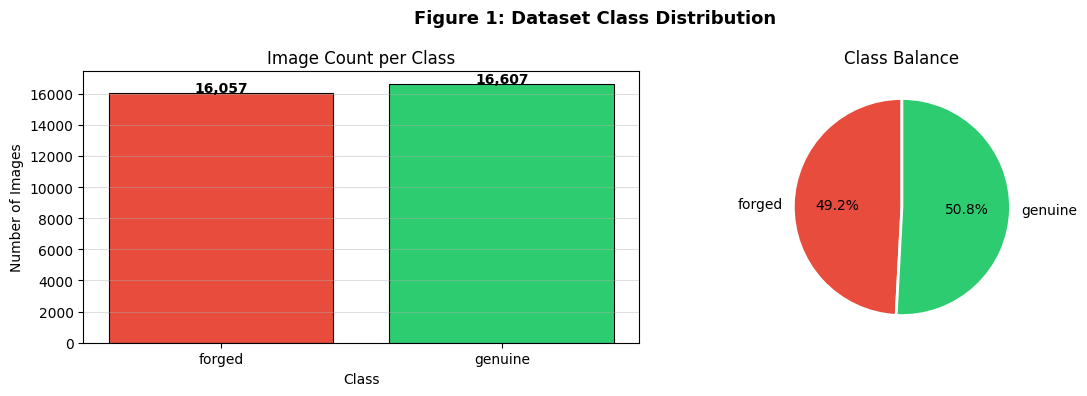

In [39]:
# ── Figure 1: Class distribution (bar + pie)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Figure 1: Dataset Class Distribution', fontsize=13, fontweight='bold')

colours = ['#E74C3C', '#2ECC71']

# Bar chart
bars = axes[0].bar(class_counts.keys(), class_counts.values(),
                   color=colours, edgecolor='black', linewidth=0.8)
axes[0].set_title('Image Count per Class')
axes[0].set_ylabel('Number of Images')
axes[0].set_xlabel('Class')
axes[0].grid(axis='y', alpha=0.4)
for bar, cnt in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 80,
                 f'{cnt:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values(), labels=class_counts.keys(),
            autopct='%1.1f%%', colors=colours, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig1_dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

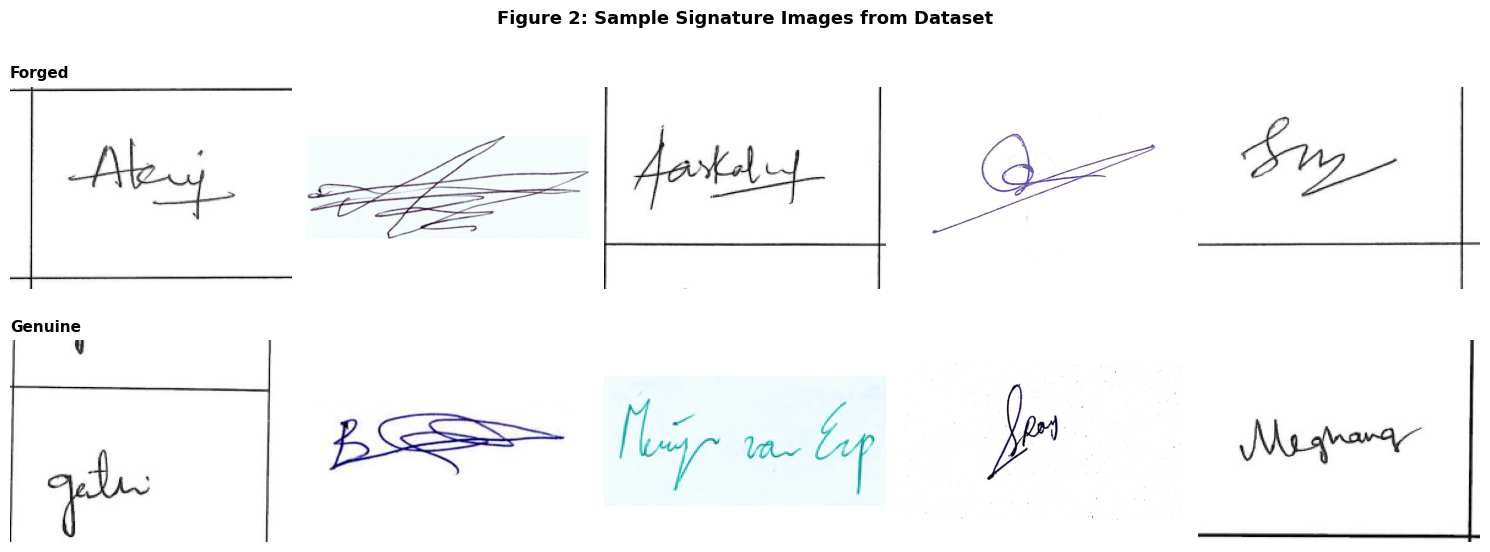

In [40]:
# ── Figure 2: Sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Figure 2: Sample Signature Images from Dataset', fontsize=13, fontweight='bold')

for row, cls in enumerate(sorted(class_counts.keys())):
    folder  = os.path.join(DATA_DIR, cls)
    samples = random.sample(os.listdir(folder), 5)
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(folder, fname)).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls.capitalize(), fontsize=11,
                                     fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig2_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 4 — Data Preprocessing & Augmentation

### Preprocessing
All images are:
- **Resized** to 224×224px — required input size for MobileNetV2 and ResNet-50
- **Normalised** from pixel range [0, 255] → [0.0, 1.0] — neural networks train better with small values

### Augmentation (Training Set Only)
Augmentation creates artificial variations of each training image on-the-fly.  
This makes the model more robust and reduces overfitting.

| Technique | Setting | Why for signatures |
|-----------|---------|--------------------|
| Horizontal flip | True | Simulates variation in writing hand/direction |
| Rotation | ±10° | Signatures are rarely perfectly level on a page |
| Zoom | ±10% | Handles size variation across different documents |
| Width/Height shift | 10% | Centres vary depending on where signature is placed |
| Shear | 5% | Mimics slight pen angle differences |
| Brightness | [0.8–1.2] | Handles different pen pressures and scan qualities |

> ⚠️ Augmentation is applied **only to training data**.  
> Validation and test sets are only rescaled — we need real-world performance numbers.

In [50]:
# ─────────────────────────────────────────────────────────────────
#  STEP 4 — Data Preprocessing & Augmentation
#
#  Images are resized to 96×96 (instead of 224×224) for speed.
#  Signatures are simple stroke images — 96×96 captures all the
#  detail needed for classification with much faster training.
#
#  Augmentation is applied to training set ONLY.
#  Validation and test sets are rescaled only — no augmentation.
# ─────────────────────────────────────────────────────────────────

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Update global image settings (overrides Step 2 values)
IMG_SIZE   = (96, 96)
IMG_SHAPE  = (96, 96, 3)
BATCH_SIZE = 64    # Larger batch = fewer steps per epoch = faster

# ── Training generator — with augmentation
train_datagen = ImageDataGenerator(
    rescale            = 1./255,       # Normalise pixels to [0, 1]
    validation_split   = 0.15,         # Reserve 15% for validation

    # ── Augmentation (training only) ────────────────────────────
    horizontal_flip    = True,         # Mirror left↔right
    rotation_range     = 10,           # Tilt up to ±10 degrees
    zoom_range         = 0.10,         # Zoom in/out by 10%
    width_shift_range  = 0.10,         # Shift horizontally 10%
    height_shift_range = 0.10,         # Shift vertically 10%
    shear_range        = 0.05,         # Slight slant
    brightness_range   = [0.8, 1.2],   # Vary brightness ±20%
    fill_mode          = 'nearest'     # Fill empty pixels
)

# ── Validation & test generator — rescale ONLY, no augmentation
eval_datagen = ImageDataGenerator(rescale=1./255)

# ── Training generator (70% of data, augmented, shuffled)
train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'binary',
    subset       = 'training',
    seed         = SEED,
    shuffle      = True
)

# ── Validation generator (15%, no augmentation)
val_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'binary',
    subset       = 'validation',
    seed         = SEED,
    shuffle      = False
)

# ── Test generator (full dataset, no augmentation, no shuffle)
# shuffle=False is critical — labels must stay in order for evaluation
test_gen = eval_datagen.flow_from_directory(
    DATA_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'binary',
    shuffle      = False
)

print('Preprocessing ready.')
print(f'  Image size : {IMG_SIZE}  <- reduced from 224x224 for speed')
print(f'  Batch size : {BATCH_SIZE}  <- increased from 32 for speed')
print(f'  IMG_SHAPE  : {IMG_SHAPE}')
print(f'  Class map  : {train_gen.class_indices}')
print(f'  Train imgs : {train_gen.samples:,}')
print(f'  Val imgs   : {val_gen.samples:,}')
print(f'  Test imgs  : {test_gen.samples:,}')

Found 27765 images belonging to 2 classes.
Found 4899 images belonging to 2 classes.
Found 32664 images belonging to 2 classes.
Preprocessing ready.
  Image size : (96, 96)  <- reduced from 224x224 for speed
  Batch size : 64  <- increased from 32 for speed
  IMG_SHAPE  : (96, 96, 3)
  Class map  : {'forged': 0, 'genuine': 1}
  Train imgs : 27,765
  Val imgs   : 4,899
  Test imgs  : 32,664


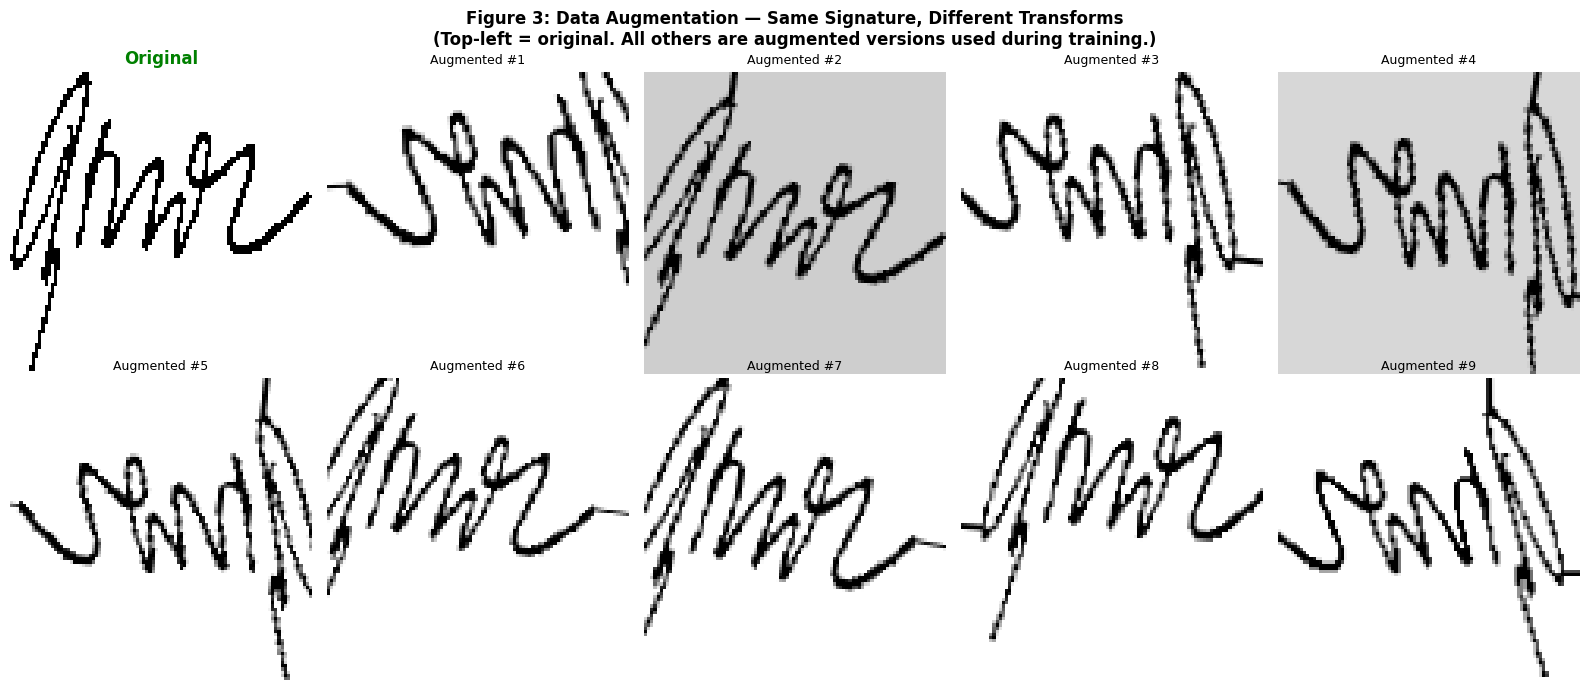

Augmentation figure saved.


In [51]:
# ── Figure 3: Augmentation effect on a real signature
# This shows visually what each augmentation does to the same image

aug_demo = ImageDataGenerator(
    rescale            = 1./255,
    horizontal_flip    = True,
    rotation_range     = 10,
    zoom_range         = 0.10,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    shear_range        = 0.05,
    brightness_range   = [0.8, 1.2]
)

# Load one sample signature image
first_class  = sorted(os.listdir(DATA_DIR))[0]
first_folder = os.path.join(DATA_DIR, first_class)
first_file   = os.path.join(first_folder, os.listdir(first_folder)[0])
orig_arr     = np.expand_dims(
    np.array(Image.open(first_file).resize(IMG_SIZE).convert('RGB')), axis=0
)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle(
    'Figure 3: Data Augmentation — Same Signature, Different Transforms\n'
    '(Top-left = original. All others are augmented versions used during training.)',
    fontsize=12, fontweight='bold'
)

# Show original
axes[0, 0].imshow(orig_arr[0] / 255.0)
axes[0, 0].set_title('Original', fontweight='bold', color='green')
axes[0, 0].axis('off')

# Show 9 augmented versions
aug_iter = aug_demo.flow(orig_arr, batch_size=1, seed=SEED)
for idx, ax in enumerate(axes.flatten()[1:]):
    aug_img = next(aug_iter)[0]
    ax.imshow(aug_img)
    ax.set_title(f'Augmented #{idx+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig3_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Augmentation figure saved.')

---
## STEP 5 — Callbacks & Helper Functions

In [52]:
# ── Callbacks — automatically improve training
def get_callbacks(name):
    """
    Returns three callbacks for a given model:
    1. EarlyStopping    — stops training if val_accuracy doesn't improve for 5 epochs
    2. ReduceLROnPlateau— halves the learning rate if val_loss stalls for 3 epochs
    3. ModelCheckpoint  — saves the best model weights automatically
    """
    return [
        EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            filepath=f'{OUT_DIR}/best_{name}.keras',
            monitor='val_accuracy',
            save_best_only=True, verbose=0
        )
    ]


# ── Plot training history
def plot_history(history, model_name, fig_num):
    """
    Plots accuracy and loss curves for training and validation.
    Curves converging = good generalisation. Large gap = overfitting.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Figure {fig_num}: Training History — {model_name}',
                 fontsize=13, fontweight='bold')

    ep = range(1, len(history['accuracy']) + 1)

    # Accuracy
    axes[0].plot(ep, history['accuracy'],     'b-o', lw=2, ms=4, label='Training')
    axes[0].plot(ep, history['val_accuracy'], 'r-s', lw=2, ms=4, label='Validation')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)

    # Loss
    axes[1].plot(ep, history['loss'],     'b-o', lw=2, ms=4, label='Training')
    axes[1].plot(ep, history['val_loss'], 'r-s', lw=2, ms=4, label='Validation')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    fname = f'{OUT_DIR}/fig{fig_num}_history_{model_name.replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


# ── Plot confusion matrix
def plot_cm(y_true, y_pred, model_name, fig_num):
    """
    Plots a labelled confusion matrix.
    Shows correct and incorrect predictions for each class.
    """
    cm   = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=['Forged', 'Genuine']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Figure {fig_num}: Confusion Matrix — {model_name}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = f'{OUT_DIR}/fig{fig_num}_cm_{model_name.replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


# ── Evaluate model and print metrics
def evaluate(model, generator, model_name, fig_num):
    """
    Runs model on the test set and prints accuracy, precision, recall, F1.
    Returns accuracy and predictions for comparison later.
    """
    generator.reset()
    y_proba = model.predict(generator, verbose=0)
    y_pred  = (y_proba > 0.5).astype(int).flatten()
    y_true  = generator.classes

    acc = accuracy_score(y_true, y_pred) * 100

    print(f'\n{"─"*52}')
    print(f'  {model_name} — Test Set Results')
    print(f'{"─"*52}')
    print(f'  Accuracy : {acc:.2f}%')
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=['Forged', 'Genuine']))
    plot_cm(y_true, y_pred, model_name, fig_num)
    return acc, y_pred, y_true


# ── Merge two training histories (used for 2-phase training)
class MergedHistory:
    """Joins two Keras History objects for unified plotting."""
    def __init__(self, h1, h2):
        self.history = {k: h1.history[k] + h2.history[k] for k in h1.history}


print('Callbacks and helper functions ready.')

Callbacks and helper functions ready.


---
## STEP 6 — Model 1: Custom CNN (Baseline)

Built entirely from scratch with no pretrained weights.  
This is our **baseline** — something to beat with transfer learning.

**Architecture — 3 Convolutional Blocks + Classifier Head:**

```
Input (224×224×3)
  → Conv Block 1: Conv(32) → BN → ReLU → Conv(32) → BN → ReLU → MaxPool → Dropout
  → Conv Block 2: Conv(64) → BN → ReLU → Conv(64) → BN → ReLU → MaxPool → Dropout  
  → Conv Block 3: Conv(128)→ BN → ReLU → Conv(128)→ BN → ReLU → MaxPool → Dropout
  → GlobalAveragePooling
  → Dense(256) → BN → Dropout(0.5)
  → Dense(64)  → Dropout(0.3)
  → Dense(1, sigmoid)  ← output: probability of being genuine
```

In [53]:
def build_custom_cnn(input_shape):
    model = models.Sequential(name='Custom_CNN')
    model.add(layers.Input(shape=input_shape))

    # ── Conv Block 1: detects low-level features — edges, pen strokes
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))   # 224→112
    model.add(layers.Dropout(0.25))

    # ── Conv Block 2: detects mid-level features — curves, loops
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))   # 112→56
    model.add(layers.Dropout(0.25))

    # ── Conv Block 3: detects high-level features — overall signature shape
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))   # 56→28
    model.add(layers.Dropout(0.25))

    # ── Classifier head
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))  # Binary output

    return model


model1 = build_custom_cnn(IMG_SHAPE)
model1.compile(
    optimizer=keras.optimizers.Adam(LEARN_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model1.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 339,361 (1.29 MB)

 Trainable params: 337,953 (1.29 MB)

 Non-trainable params: 1,408 (5.50 KB)

Training Model 1: Custom CNN (Baseline)...
Epoch 1/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 170s 360ms/step - accuracy: 0.5112 - loss: 0.8297 - val_accuracy: 0.5085 - val_loss: 0.8383 - learning_rate: 1.0000e-04
Epoch 2/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 144s 332ms/step - accuracy: 0.5308 - loss: 0.7450 - val_accuracy: 0.5279 - val_loss: 0.8245 - learning_rate: 1.0000e-04
Epoch 3/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 146s 335ms/step - accuracy: 0.5402 - loss: 0.7246 - val_accuracy: 0.5158 - val_loss: 0.8148 - learning_rate: 1.0000e-04
Epoch 4/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 146s 337ms/step - accuracy: 0.5478 - loss: 0.7039 - val_accuracy: 0.5148 - val_loss: 0.9563 - learning_rate: 1.0000e-04
Epoch 5/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 144s 333ms/step - accuracy: 0.5685 - loss: 0.6877 - val_accuracy: 0.5081 - val_loss: 1.5690 - learning_rate: 1.0000e-04
Epoch 6/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.5774 - loss: 0.6787
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.99999987368937

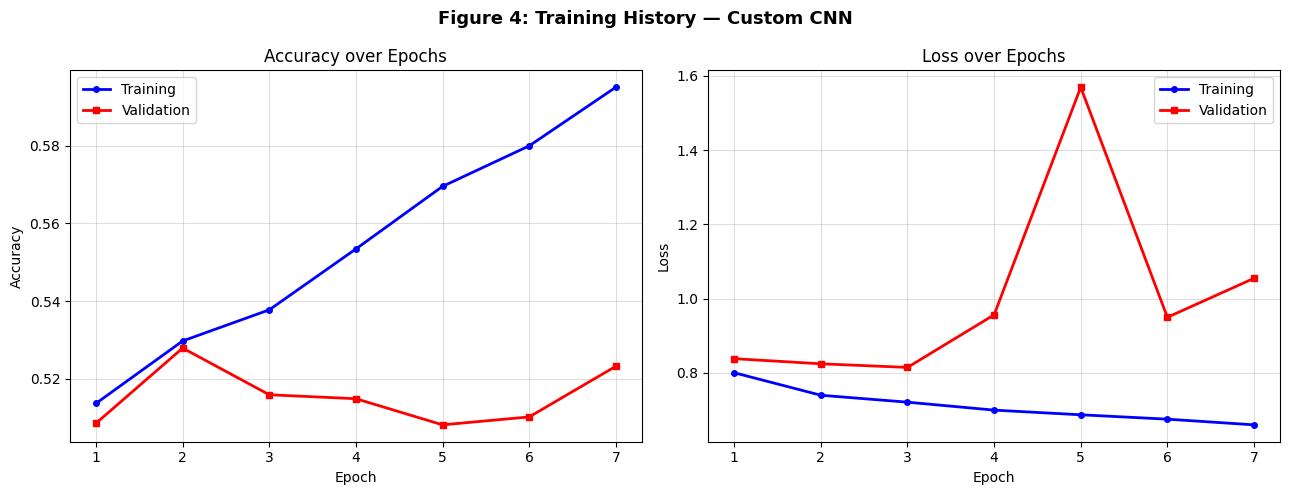

In [54]:
print('Training Model 1: Custom CNN (Baseline)...')
history1 = model1.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('custom_cnn'),
    verbose=1
)
plot_history(history1.history, 'Custom CNN', fig_num=4)


────────────────────────────────────────────────────
  Custom CNN — Test Set Results
────────────────────────────────────────────────────
  Accuracy : 52.76%

              precision    recall  f1-score   support

      Forged       0.54      0.26      0.35     16057
     Genuine       0.52      0.79      0.63     16607

    accuracy                           0.53     32664
   macro avg       0.53      0.52      0.49     32664
weighted avg       0.53      0.53      0.49     32664



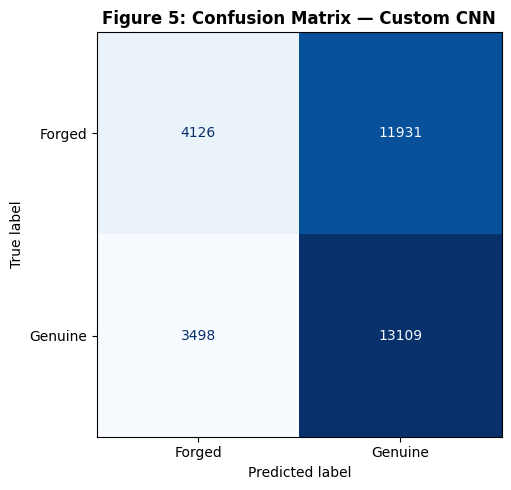

In [55]:
acc1, ypred1, ytrue1 = evaluate(model1, test_gen, 'Custom CNN', fig_num=5)

---
## STEP 7 — Model 2: MobileNetV2 (Transfer Learning)

MobileNetV2 was pretrained on **ImageNet** (1.2M images, 1000 classes).  
Its layers already know how to detect edges, textures and shapes.  
We reuse those layers and only teach it the signature-specific task.

**Two-phase training strategy:**
- **Phase 1 (5 epochs):** Freeze base, train new classifier head only  
- **Phase 2 (up to 20 epochs):** Unfreeze top 30 layers, fine-tune at 10× smaller LR

In [56]:
def build_transfer_model(base_model_fn, input_shape, name):
    """
    Generic transfer learning builder.
    Takes any pretrained base and attaches our custom classifier head.
    """
    base = base_model_fn(input_shape=input_shape,
                         include_top=False, weights='imagenet')
    base.trainable = False   # Freeze initially

    inputs  = keras.Input(shape=input_shape)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(64, activation='relu')(x)
    x       = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name=name)
    return model, base


model2, base2 = build_transfer_model(MobileNetV2, IMG_SHAPE, 'MobileNetV2_Transfer')
model2.compile(
    optimizer=keras.optimizers.Adam(LEARN_RATE),
    loss='binary_crossentropy', metrics=['accuracy']
)
model2.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,457 (9.93 MB)

 Trainable params: 344,961 (1.32 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Model 2 Phase 1: Training classifier head...
Epoch 1/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 146s 337ms/step - accuracy: 0.5882 - loss: 0.7106 - val_accuracy: 0.6814 - val_loss: 0.5922 - learning_rate: 1.0000e-04
Epoch 3/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 147s 338ms/step - accuracy: 0.6008 - loss: 0.6848 - val_accuracy: 0.6685 - val_loss: 0.5840 - learning_rate: 1.0000e-04
Epoch 4/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 146s 337ms/step - accuracy: 0.6149 - loss: 0.6568 - val_accuracy: 0.6799 - val_loss: 0.5773 - learning_rate: 1.0000e-04
Epoch 5/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 147s 339ms/step - accuracy: 0.6245 - loss: 0.6453 - val_accuracy: 0.6881 - val_loss: 0.5608 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 5.

Model 2 Phase 2: Fine-tuning top 30 layers...
Epoch 1/20


2026-04-28 19:00:42.997192: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 19:00:43.181329: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 19:00:43.451629: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 19:00:43.660873: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 91/434 ━━━━━━━━━━━━━━━━━━━━ 1:37 285ms/step - accuracy: 0.5519 - loss: 0.7614

2026-04-28 19:01:17.624467: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 19:01:17.811453: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 19:01:18.081140: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 19:01:18.288551: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


434/434 ━━━━━━━━━━━━━━━━━━━━ 182s 377ms/step - accuracy: 0.5660 - loss: 0.7372 - val_accuracy: 0.6487 - val_loss: 0.6305 - learning_rate: 1.0000e-05
Epoch 2/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 147s 339ms/step - accuracy: 0.5911 - loss: 0.7016 - val_accuracy: 0.6301 - val_loss: 0.6881 - learning_rate: 1.0000e-05
Epoch 3/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 147s 339ms/step - accuracy: 0.6119 - loss: 0.6809 - val_accuracy: 0.6414 - val_loss: 0.6504 - learning_rate: 1.0000e-05
Epoch 4/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 148s 340ms/step - accuracy: 0.6232 - loss: 0.6624 - val_accuracy: 0.6644 - val_loss: 0.6075 - learning_rate: 1.0000e-05
Epoch 5/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 147s 339ms/step - accuracy: 0.6277 - loss: 0.6484 - val_accuracy: 0.6695 - val_loss: 0.5892 - learning_rate: 1.0000e-05
Epoch 6/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 148s 340ms/step - accuracy: 0.6422 - loss: 0.6361 - val_accuracy: 0.6897 - val_loss: 0.5733 - learning_rate: 1.0000e-05
Epoch 7/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 147s 339ms/

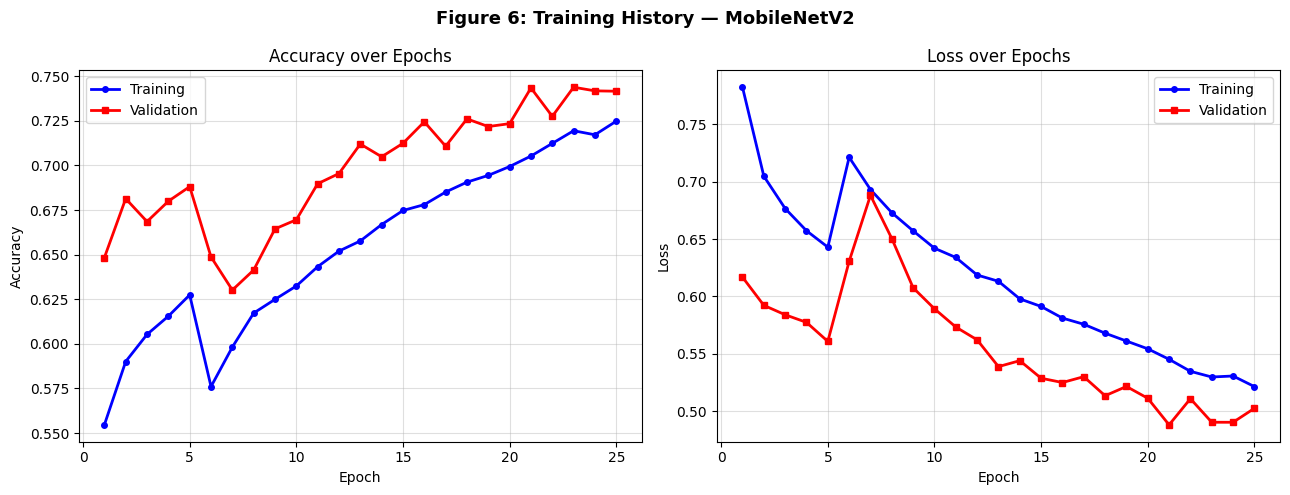

In [57]:
# Phase 1 — train head only
print('Model 2 Phase 1: Training classifier head...')
h2a = model2.fit(train_gen, epochs=5, validation_data=val_gen,
                 callbacks=get_callbacks('mobilenetv2_p1'), verbose=1)

# Phase 2 — unfreeze top layers and fine-tune
print('\nModel 2 Phase 2: Fine-tuning top 30 layers...')
base2.trainable = True
for layer in base2.layers[:-30]:
    layer.trainable = False

model2.compile(
    optimizer=keras.optimizers.Adam(LEARN_RATE / 10),  # 10× smaller LR
    loss='binary_crossentropy', metrics=['accuracy']
)
h2b = model2.fit(train_gen, epochs=EPOCHS, validation_data=val_gen,
                 callbacks=get_callbacks('mobilenetv2_p2'), verbose=1)

history2 = MergedHistory(h2a, h2b)
plot_history(history2.history, 'MobileNetV2', fig_num=6)


────────────────────────────────────────────────────
  MobileNetV2 — Test Set Results
────────────────────────────────────────────────────
  Accuracy : 74.19%

              precision    recall  f1-score   support

      Forged       0.76      0.69      0.72     16057
     Genuine       0.73      0.79      0.76     16607

    accuracy                           0.74     32664
   macro avg       0.74      0.74      0.74     32664
weighted avg       0.74      0.74      0.74     32664



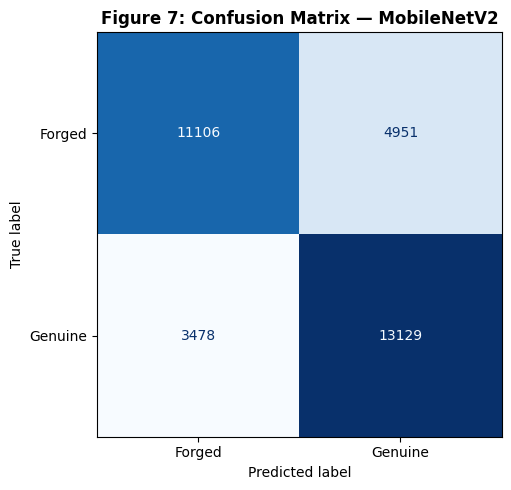

In [58]:
acc2, ypred2, ytrue2 = evaluate(model2, test_gen, 'MobileNetV2', fig_num=7)

---
## STEP 8 — Model 3: ResNet-50 (Transfer Learning)

ResNet-50 uses **residual (skip) connections**: `output = F(x) + x`  
This allows gradients to flow more freely through deep layers,  
preventing the vanishing gradient problem and enabling much deeper networks.  
It may pick up more complex forgery patterns than MobileNetV2.

In [59]:
model3, base3 = build_transfer_model(ResNet50, IMG_SHAPE, 'ResNet50_Transfer')
model3.compile(
    optimizer=keras.optimizers.Adam(LEARN_RATE),
    loss='binary_crossentropy', metrics=['accuracy']
)
model3.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,129,793 (92.05 MB)

 Trainable params: 541,569 (2.07 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

Model 3 Phase 1: Training classifier head...
Epoch 1/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 170s 362ms/step - accuracy: 0.5052 - loss: 0.7643 - val_accuracy: 0.5050 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 2/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 145s 334ms/step - accuracy: 0.5289 - loss: 0.7208 - val_accuracy: 0.5309 - val_loss: 0.6934 - learning_rate: 1.0000e-04
Epoch 3/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 144s 331ms/step - accuracy: 0.5296 - loss: 0.7097 - val_accuracy: 0.5268 - val_loss: 0.6879 - learning_rate: 1.0000e-04
Epoch 4/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 144s 332ms/step - accuracy: 0.5367 - loss: 0.7042 - val_accuracy: 0.5150 - val_loss: 0.7309 - learning_rate: 1.0000e-04
Epoch 5/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 146s 336ms/step - accuracy: 0.5437 - loss: 0.6960 - val_accuracy: 0.5072 - val_loss: 0.6971 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 2.

Model 3 Phase 2: Fine-tuning top 30 layers...
Epoch 1/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 181s 370ms/ste

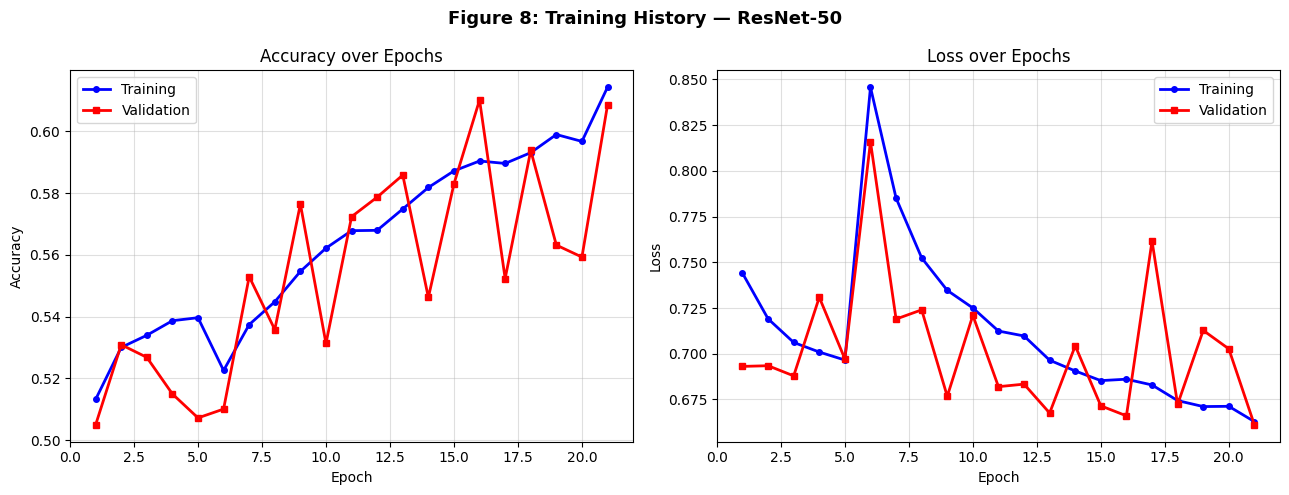

In [60]:
# Phase 1
print('Model 3 Phase 1: Training classifier head...')
h3a = model3.fit(train_gen, epochs=5, validation_data=val_gen,
                 callbacks=get_callbacks('resnet50_p1'), verbose=1)

# Phase 2
print('\nModel 3 Phase 2: Fine-tuning top 30 layers...')
base3.trainable = True
for layer in base3.layers[:-30]:
    layer.trainable = False

model3.compile(
    optimizer=keras.optimizers.Adam(LEARN_RATE / 10),
    loss='binary_crossentropy', metrics=['accuracy']
)
h3b = model3.fit(train_gen, epochs=EPOCHS, validation_data=val_gen,
                 callbacks=get_callbacks('resnet50_p2'), verbose=1)

history3 = MergedHistory(h3a, h3b)
plot_history(history3.history, 'ResNet-50', fig_num=8)


────────────────────────────────────────────────────
  ResNet-50 — Test Set Results
────────────────────────────────────────────────────
  Accuracy : 62.56%

              precision    recall  f1-score   support

      Forged       0.60      0.70      0.65     16057
     Genuine       0.66      0.56      0.60     16607

    accuracy                           0.63     32664
   macro avg       0.63      0.63      0.62     32664
weighted avg       0.63      0.63      0.62     32664



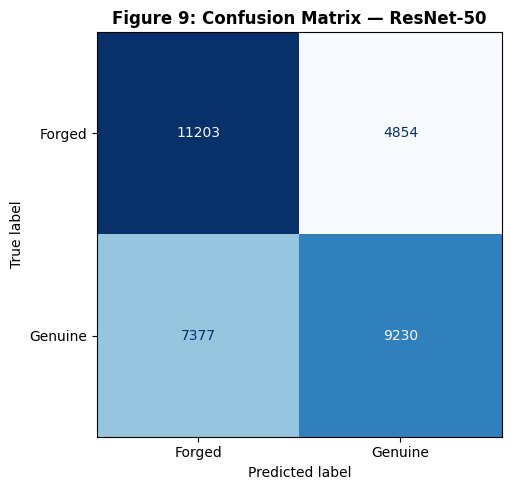

In [61]:
acc3, ypred3, ytrue3 = evaluate(model3, test_gen, 'ResNet-50', fig_num=9)

---
## STEP 9 — Full Comparison of All 3 Models

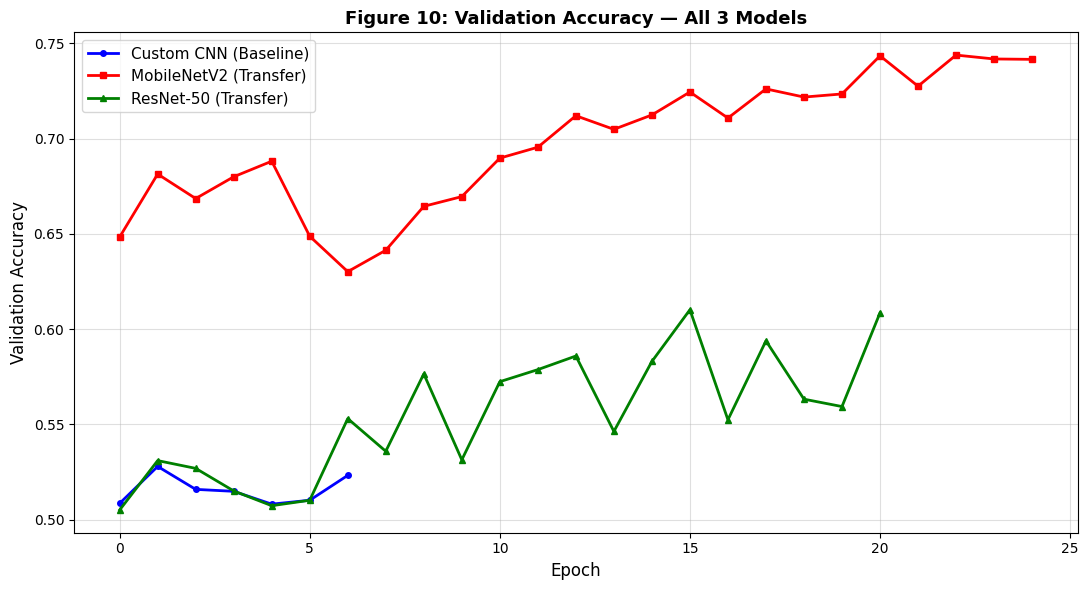

In [62]:
# ── Figure 10: Combined validation accuracy curve
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(history1.history['val_accuracy'], 'b-o', lw=2, ms=4, label='Custom CNN (Baseline)')
ax.plot(history2.history['val_accuracy'], 'r-s', lw=2, ms=4, label='MobileNetV2 (Transfer)')
ax.plot(history3.history['val_accuracy'], 'g-^', lw=2, ms=4, label='ResNet-50 (Transfer)')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Figure 10: Validation Accuracy — All 3 Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig10_accuracy_curve_all.png', dpi=150, bbox_inches='tight')
plt.show()

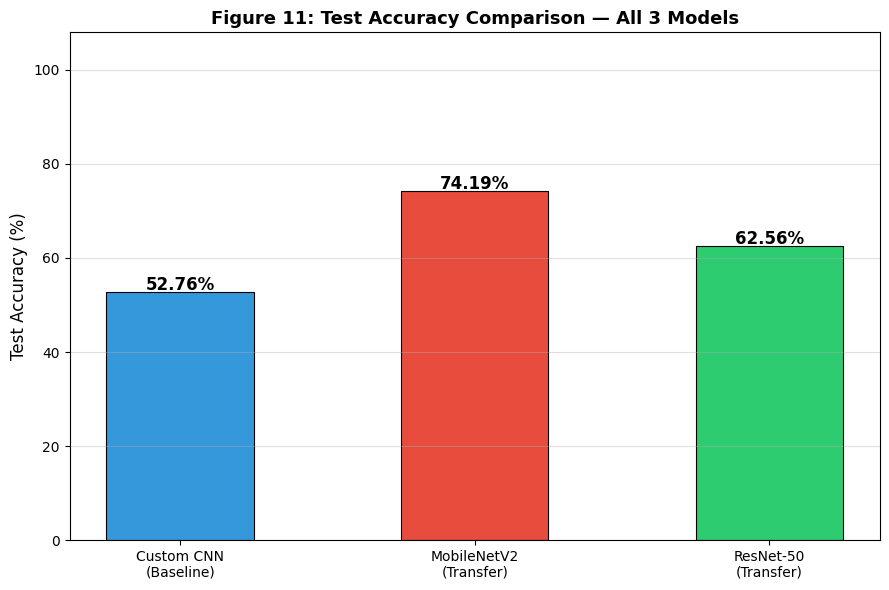

In [63]:
# ── Figure 11: Test accuracy bar chart
names  = ['Custom CNN\n(Baseline)', 'MobileNetV2\n(Transfer)', 'ResNet-50\n(Transfer)']
accs   = [acc1, acc2, acc3]
cols   = ['#3498DB', '#E74C3C', '#2ECC71']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(names, accs, color=cols, edgecolor='black', linewidth=0.8, width=0.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Figure 11: Test Accuracy Comparison — All 3 Models',
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 108])
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig11_test_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
# ── Final summary table
rows = []
for name, acc, y_t, y_p in [
    ('Custom CNN (Baseline)',   acc1, ytrue1, ypred1),
    ('MobileNetV2 (Transfer)',  acc2, ytrue2, ypred2),
    ('ResNet-50 (Transfer)',    acc3, ytrue3, ypred3)
]:
    rows.append({
        'Model'      : name,
        'Accuracy %' : f'{acc:.2f}',
        'Precision'  : f'{precision_score(y_t, y_p):.4f}',
        'Recall'     : f'{recall_score(y_t, y_p):.4f}',
        'F1-Score'   : f'{f1_score(y_t, y_p):.4f}'
    })

summary_df = pd.DataFrame(rows)

print('\n' + '='*62)
print('         FINAL MODEL COMPARISON SUMMARY')
print('='*62)
print(summary_df.to_string(index=False))
print('='*62)

best = rows[accs.index(max(accs))]
print(f"\n  Best performing model : {best['Model']}")
print(f"  Test Accuracy         : {best['Accuracy %']}%")
print(f"  F1-Score              : {best['F1-Score']}")


         FINAL MODEL COMPARISON SUMMARY
                 Model Accuracy % Precision Recall F1-Score
 Custom CNN (Baseline)      52.76    0.5235 0.7894   0.6295
MobileNetV2 (Transfer)      74.19    0.7262 0.7906   0.7570
  ResNet-50 (Transfer)      62.56    0.6554 0.5558   0.6015

  Best performing model : MobileNetV2 (Transfer)
  Test Accuracy         : 74.19%
  F1-Score              : 0.7570


---
## STEP 10 — All Figures Are Saved

All output figures are saved to `/kaggle/working/`.  
You can download them from the **Output** tab on the right panel of Kaggle.  
Use them directly in your coursework report.

| File | Report Section |
|------|----------------|
| `fig1_dataset_distribution.png` | Simulations — Dataset Description |
| `fig2_sample_images.png` | Simulations — Dataset Description |
| `fig3_augmentation.png` | Simulations — Preprocessing |
| `fig4_history_Custom_CNN.png` | Results — Accuracy Curve |
| `fig5_cm_Custom_CNN.png` | Results — Confusion Matrix |
| `fig6_history_MobileNetV2.png` | Results — Accuracy Curve |
| `fig7_cm_MobileNetV2.png` | Results — Confusion Matrix |
| `fig8_history_ResNet-50.png` | Results — Accuracy Curve |
| `fig9_cm_ResNet-50.png` | Results — Confusion Matrix |
| `fig10_accuracy_curve_all.png` | Results — Comparison |
| `fig11_test_accuracy_comparison.png` | Results — Comparison |